In [18]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/retrospective_t2e/')

from gls import datasets

import pandas as pd
import numpy as np

def load_oat_trial_data():

  feature_list = {
    # demographic data
    'oat2166.sas7bdat' : ['TRT_GRP', 'age', 'male', 'diabhx', 'finalrace', 'cursmoke', 'mihx', 'htenhx',
                          'cerevashx', 'pvdhx', 'chfhx', 'pcihx', 'insulin', 'anginahx', 'killip24', 'white',
                          'multi', 'collany', 'ckd', 'EFall', 'EFall50', 'iraall', 'ladall', 'cabghx', 'nyharand',
                          'EFall40', 'thromb', 'strestst', 'stira', 'pregrade', 'nitrat1d', 'bbd',
                          'ccbd', 'aspirind', 'ticlopd', 'clopidd', 'warfrnd', 'digoxind', 'diurd', 'spirod', 'insulind',
                          'orhypogd', 'lipidlod', 'eitherd', 'acearbd', 'atleast1', 'atleast2', 'asporclopd', 'aspandclopd']
  }
  outcomes, features = datasets._load_generic_biolincc_dataset('oat2166.sas7bdat', 
                                                                   'combdays', 'combfv',
                                                                   features=feature_list, 
                                                                   id_col='NEWID',
                                                                   location='datasets/OAT/Ancillary/')

  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 
  
  NaNindex = pd.isna(outcomes.time)
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]

  return outcomes, features

In [2]:
import pandas as pd
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
# Load the synthetic dataset
outcomes, features = load_oat_trial_data()

# Let's take a look at take the dataset
features.head(5)

(2166, 49)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\retrospective_t2e\auton_survival\gls\datasets.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11020\2137431757.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes.event = outcomes.event == 1.0


,anginahx,nyharand,iraall,mihx,insulind,EFall40,ccbd,pcihx,collany,orhypogd,...,lipidlod,chfhx,aspandclopd,warfrnd,cabghx,thromb,EFall50,stira,diabhx,nitrat1d
NEWID,,,,,,,,,,,,,,,,,,,,,
3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
5.0,1.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0.0,0.0
16.0,0.0,2.0,3.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN,1.0,0.0
20.0,0.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0
21.0,0.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0


In [6]:
interventions = features['TRT_GRP']
interventions

NEWID
3.0       1
5.0       2
16.0      1
20.0      1
21.0      2
         ..
9969.0    2
9972.0    1
9973.0    2
9981.0    1
9988.0    2
Name: TRT_GRP, Length: 2166, dtype: object

In [21]:
from preprocessing import Preprocessor

cat_feats = ['male', 'diabhx', 'finalrace', 'cursmoke', 'mihx', 'htenhx',
                          'cerevashx', 'pvdhx', 'chfhx', 'pcihx', 'insulin', 'anginahx', 'killip24', 'white',
                          'multi', 'collany', 'EFall50', 'iraall', 'ladall', 'cabghx', 'nyharand',
                          'EFall40', 'thromb', 'strestst', 'stira', 'pregrade', 'nitrat1d', 'bbd',
                          'ccbd', 'aspirind', 'ticlopd', 'clopidd', 'warfrnd', 'digoxind', 'diurd', 'spirod', 'insulind',
                          'orhypogd', 'lipidlod', 'eitherd', 'acearbd', 'atleast1', 'atleast2', 'asporclopd', 'aspandclopd',]
num_feats = ['age', 'EFall', 'ckd']

features = Preprocessor().fit_transform(features[cat_feats+num_feats], 
                                                cat_feats=cat_feats, num_feats=num_feats)

In [22]:
features.head(5)

,age,EFall,ckd,male_1.0,diabhx_1.0,finalrace_2.0,finalrace_3.0,finalrace_4.0,cursmoke_1.0,mihx_1.0,...,spirod_1.0,insulind_1.0,orhypogd_1.0,lipidlod_1.0,eitherd_1.0,acearbd_1.0,atleast1_1.0,atleast2_1.0,asporclopd_1.0,aspandclopd_1.0
NEWID,,,,,,,,,,,,,,,,,,,,,
3.0,-1.517989,-1.597806,-0.113322,1,0,0,0,0,1,0,...,0,0,0,1,1,1,1,1,1,1
5.0,0.308861,1.110988,-0.009062,1,0,0,0,0,1,0,...,0,0,0,1,0,1,1,0,1,0
16.0,1.222285,0.027470,-1.076045,1,1,0,0,0,1,0,...,0,0,1,1,1,1,1,1,1,1
20.0,-0.330537,-0.243409,0.582532,1,0,0,0,0,1,0,...,0,0,0,1,1,0,1,1,1,1
21.0,1.678998,0.027470,-1.517877,1,0,0,0,0,0,0,...,0,0,0,1,0,1,1,0,1,0


In [23]:
# Hyper-parameters
random_seed = 0
test_size = 0.4

# Split the synthetic data into training and testing data
import numpy as np

np.random.seed(random_seed)
n = features.shape[0] 

test_idx = np.zeros(n).astype('bool')
test_idx[np.random.randint(n, size=int(n*test_size))] = True 

features_tr = features.iloc[~test_idx] 
outcomes_tr = outcomes.iloc[~test_idx]
interventions_tr = interventions[~test_idx]
print(f'Number of training data points: {len(features_tr)}')

features_te = features.iloc[test_idx] 
outcomes_te = outcomes.iloc[test_idx]
interventions_te = interventions[test_idx]
print(f'Number of test data points: {len(features_te)}')

x_tr = features_tr.values.astype('float32')
t_tr = outcomes_tr['time'].values.astype('float32')
e_tr = outcomes_tr['event'].values.astype('float32')
a_tr = interventions_tr.values.astype('float32')

x_te = features_te.values.astype('float32')
t_te = outcomes_te['time'].values.astype('float32')
e_te = outcomes_te['event'].values.astype('float32')
a_te = interventions_te.values.astype('float32')

print('Training Data Statistics:')
print(f'Shape of covariates: {x_tr.shape} | times: {t_tr.shape} | events: {e_tr.shape} | interventions: {a_tr.shape}')

Number of training data points: 1455
Number of test data points: 711
Training Data Statistics:
Shape of covariates: (1455, 55) | times: (1455,) | events: (1455,) | interventions: (1455,)


In [24]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 128 
vsize = 0.15 # size of the validation split
patience = 3
optimizer = "Adam"

In [26]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers)

model = model.fit(x_tr, t_tr, e_tr, a_tr, vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:08<00:00, 12.15it/s]


In [27]:
zeta_probs_train = model.predict_latent_phi(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)
zeta_train

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [28]:
zeta_train.mean()

0.9518900343642611

In [29]:
idx_list_0 = np.where(zeta_train == 0)

In [30]:
idx_list_1 = np.where(zeta_train == 1)

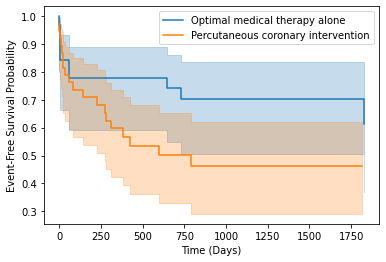

In [31]:
from auton_survival import reporting
import matplotlib.pyplot as plt

# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax = reporting.plot_kaplanmeier(outcomes_tr.iloc[idx_list_0], interventions_tr.iloc[idx_list_0])
h, l = ax.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Optimal medical therapy alone', 'Percutaneous coronary intervention'], loc="upper right")
plt.show()

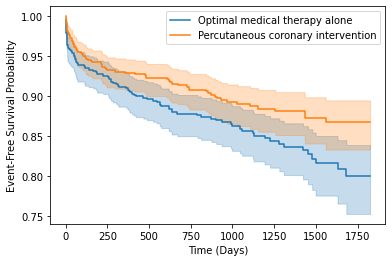

In [32]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax = reporting.plot_kaplanmeier(outcomes_tr.iloc[idx_list_1], interventions_tr.iloc[idx_list_1])
h, l = ax.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Optimal medical therapy alone', 'Percutaneous coronary intervention'], loc="upper right")
plt.show()

In [33]:
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
zeta_test

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,

In [34]:
zeta_test.mean()

0.9549929676511955

In [35]:
idx_list_0te = np.where(zeta_test == 0)
idx_list_1te = np.where(zeta_test == 1)

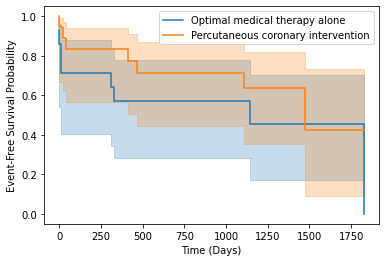

In [36]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax3 = reporting.plot_kaplanmeier(outcomes_te.iloc[idx_list_0te], interventions_te.iloc[idx_list_0te])
h, l = ax3.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Optimal medical therapy alone', 'Percutaneous coronary intervention'], loc="upper right")
plt.show()

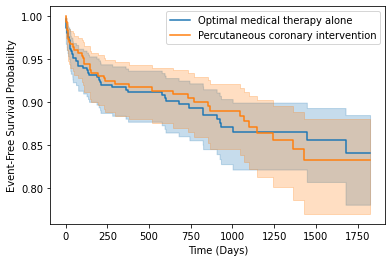

In [37]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax4 = reporting.plot_kaplanmeier(outcomes_te.iloc[idx_list_1te], interventions_te.iloc[idx_list_1te])
h, l = ax4.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Optimal medical therapy alone', 'Percutaneous coronary intervention'], loc="upper right")
plt.show()